In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('amazon_sales_dataset.csv')
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [3]:
df.shape

(50000, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


In [5]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


In [7]:
df.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

<Axes: >

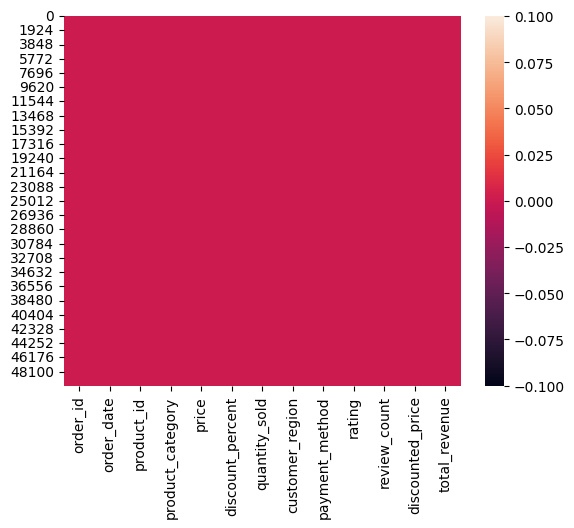

In [8]:
sns.heatmap(df.isnull())

In [9]:
print("Total duplicated rows=",df.duplicated().sum())

Total duplicated rows= 0


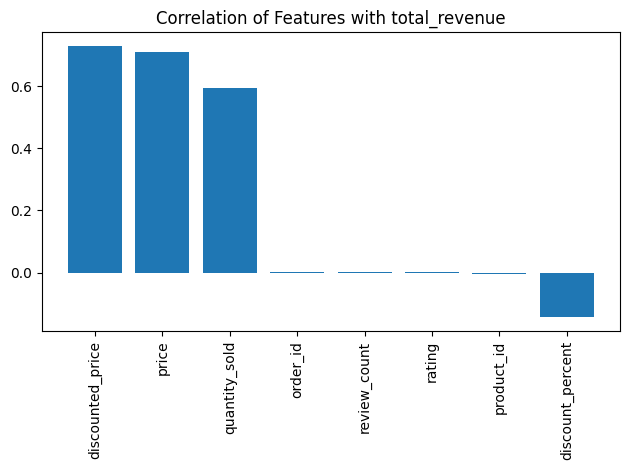

In [13]:
corrl=df.corr(numeric_only=True)['total_revenue'].sort_values(ascending=False)

plt.bar(corrl.drop('total_revenue').index, corrl.drop('total_revenue').values)
plt.title("Correlation of Features with total_revenue")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [14]:
# Drop unnecessary columns

cols_to_drop = ['order_id', 'product_id']

df = df.drop(columns=cols_to_drop)


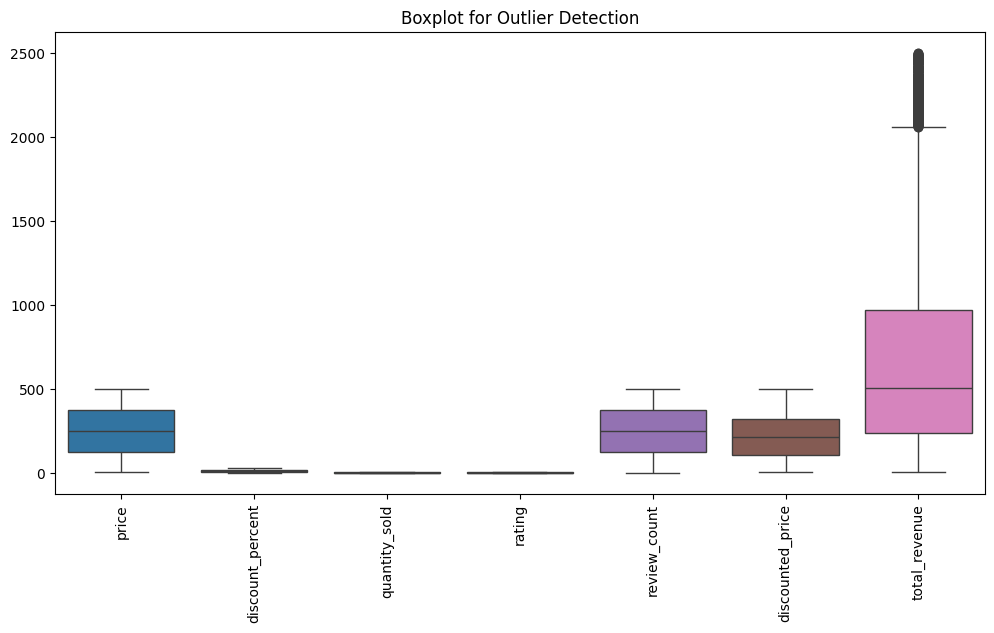

In [15]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

In [16]:
#Removing visible outliers from the dataset...

mean = df['total_revenue'].mean()
std = df['total_revenue'].std()

lower_bound = mean - 3 * std
upper_bound = mean + 3 * std

In [17]:
outliers = df[(df['total_revenue'] < lower_bound) |
(df['total_revenue'] > upper_bound)]

print("Outliers removed:", len(outliers))

df=df[(df['total_revenue']>=lower_bound) & (df['total_revenue'] <= upper_bound)]

Outliers removed: 286


<Axes: xlabel='total_revenue'>

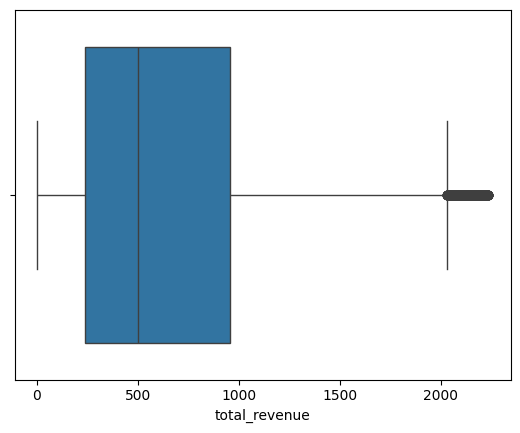

In [18]:
sns.boxplot(df['total_revenue'],orient='h')

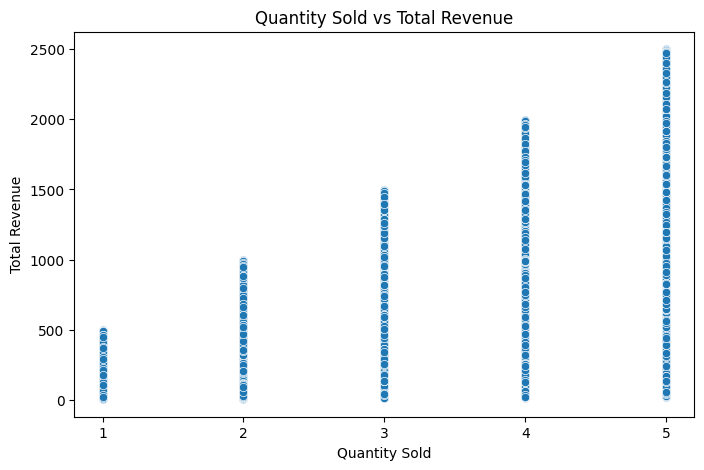

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='quantity_sold', y='total_revenue', data=df)

plt.title("Quantity Sold vs Total Revenue")
plt.xticks([1.0, 2.0, 3.0, 4.0, 5.0])
plt.xlabel("Quantity Sold")
plt.ylabel("Total Revenue")

plt.show()

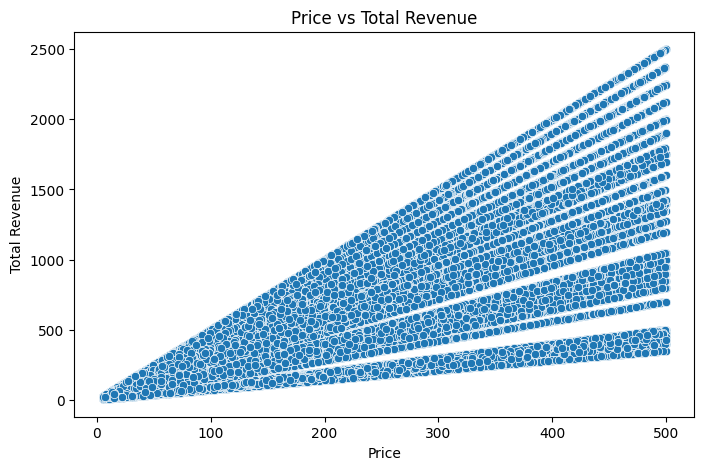

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='price', y='total_revenue', data=df)

plt.title("Price vs Total Revenue")
plt.xlabel("Price")
plt.ylabel("Total Revenue")
plt.show()

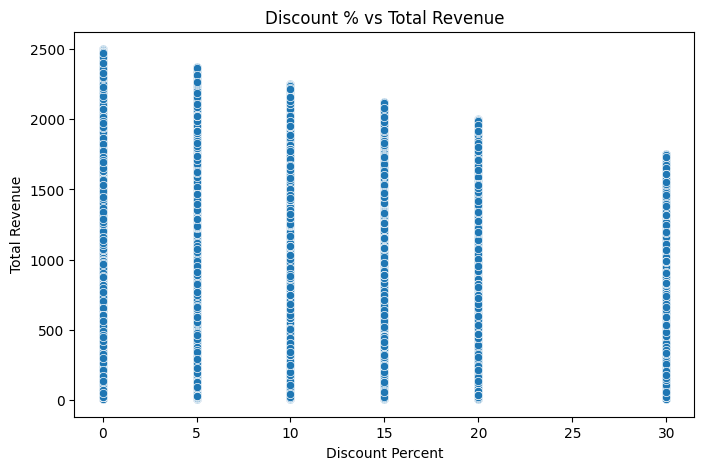

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='discount_percent', y='total_revenue', data=df)

plt.title("Discount % vs Total Revenue")
plt.xlabel("Discount Percent")
plt.ylabel("Total Revenue")
plt.show()


Value counts for order_date:
order_date
2023-10-19    93
2022-04-16    89
2022-12-09    88
2022-10-20    88
2023-03-14    87
              ..
2022-04-01    51
2023-07-06    51
2022-01-15    50
2023-02-22    50
2023-04-15    48
Name: count, Length: 730, dtype: int64


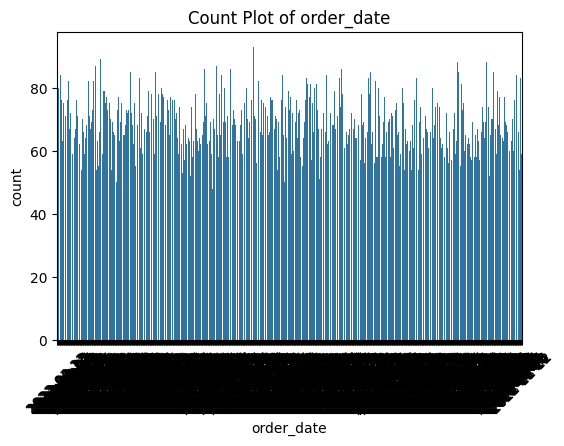


Value counts for product_category:
product_category
Beauty            8465
Fashion           8365
Books             8327
Electronics       8320
Sports            8265
Home & Kitchen    8258
Name: count, dtype: int64


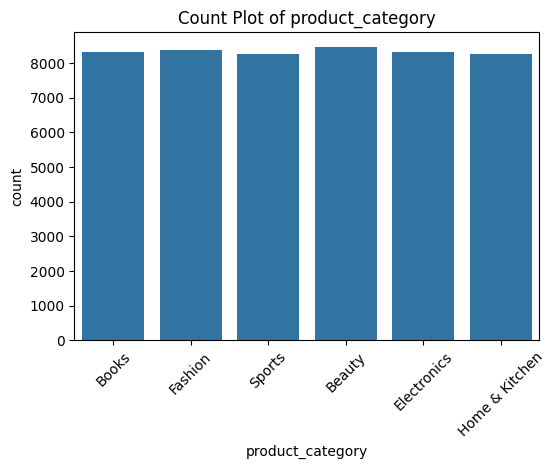


Value counts for customer_region:
customer_region
Asia             12526
North America    12517
Middle East      12505
Europe           12452
Name: count, dtype: int64


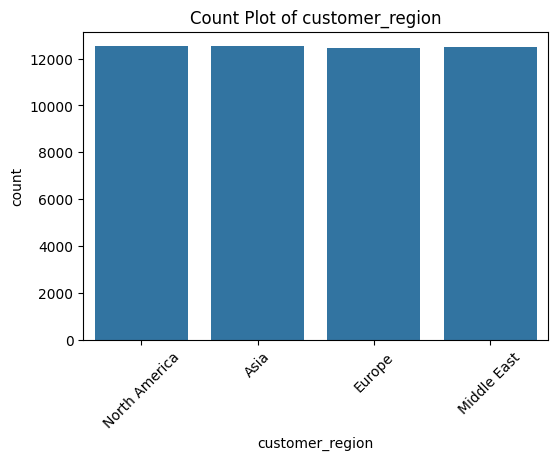


Value counts for payment_method:
payment_method
Wallet              10106
UPI                 10078
Debit Card           9981
Cash on Delivery     9927
Credit Card          9908
Name: count, dtype: int64


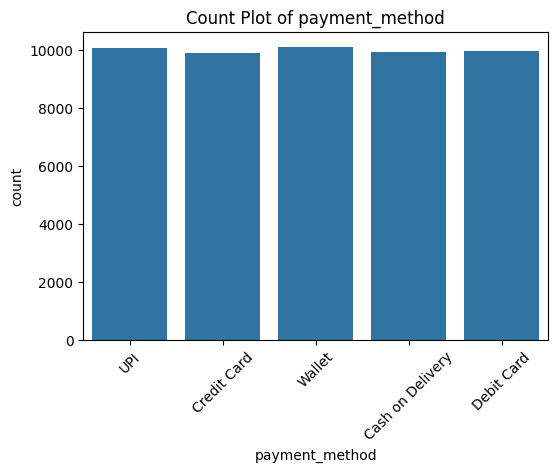

In [ ]:
# WTFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF


categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())
    
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f"Count Plot of {col}")
    plt.show()

In [20]:
df.head()

,order_date,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,2022-04-13,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2023-03-12,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,2022-09-28,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,2022-04-17,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,2022-03-13,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [21]:
df.to_csv('final_dataset.csv', index=False)